# Тестирование реализации на наборе Human Activity Recognition

## Загрузка данных

В данном блокноте проведём тестирование собственной реализации, а также сравнение её по основным параметрам: ошибка, точность, скорость выполнения и потребление память с реализацией, с функцией, предоставленной в библиотеке sklearn 

Также визуализируем полученные результаты и опишем их

Загружаем все необходимые модули для дальнейшего

In [1]:
from tsne import tsne

import numpy as np
import matplotlib.pyplot as plt
import time
import os
import psutil
from matplotlib.colors import ListedColormap
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

Загружаем в переменную X набор HumanActivity (содержит данные о 7352 активностях людей, основанные на данных гироскопа, описанные 562 переменными)

activities - набор самих активностей

Также отсекаю 2500 первых записей (для ускорения вычислений) и перемешиваю их

In [2]:
df = pd.read_csv('HumanActivity.csv', sep=',')
df_cropped = df.head(2500)

df_shuffled = df_cropped.sample(frac=1).reset_index(drop=True)

X = df_shuffled.iloc[:, :-1].values
activities = df_shuffled.iloc[:, -1].values

## Сравнение по времени, потреблению памяти и ошибке

In [3]:
process = psutil.Process(os.getpid())
start_time = time.time()
start_memory = process.memory_info().rss

Y = tsne(X) 

end_time = time.time()
end_memory = process.memory_info().rss

execution_time = end_time - start_time
memory_used_mb = (end_memory - start_memory) / (1024 * 1024)
total_memory_mb = end_memory / (1024 * 1024)

print(f"\nВремя выполнения: {execution_time:.2f} сек.")
print(f"Прирост памяти во время t-SNE: {memory_used_mb:.2f} MB")
print(f"Итоговое потребление памяти процессом: {total_memory_mb:.2f} MB")

Среднее значение sigma: 1.236038
Итерация 1000: значение функции потерь (KL) = 0.504257

Время выполнения: 397.36 сек.
Прирост памяти во время t-SNE: 14.27 MB
Итоговое потребление памяти процессом: 282.68 MB


In [4]:
process = psutil.Process(os.getpid())
start_time = time.time()
start_memory = process.memory_info().rss

pca_transformer = PCA(n_components=50)
X_reduced = pca_transformer.fit_transform(X)

tsne_transformer = TSNE(n_components=2,         
    perplexity=30.0,         
    learning_rate=500.0,
    max_iter=1000)
Y_sklearn = tsne_transformer.fit_transform(X_reduced)

end_time = time.time()
end_memory = process.memory_info().rss

execution_time = end_time - start_time
memory_used_mb = (end_memory - start_memory) / (1024 * 1024)
total_memory_mb = end_memory / (1024 * 1024)

print(f"Значение функции потерь (KL) = {tsne_transformer.kl_divergence_:.4f}")

print(f"\nВремя выполнения: {execution_time:.2f} сек.")
print(f"Прирост памяти во время t-SNE: {memory_used_mb:.2f} MB")
print(f"Итоговое потребление памяти процессом: {total_memory_mb:.2f} MB")

Значение функции потерь (KL) = 0.5345

Время выполнения: 32.18 сек.
Прирост памяти во время t-SNE: 7.88 MB
Итоговое потребление памяти процессом: 291.19 MB


Что видим:

1) Ошибка (дивергенция Кульбека-Лейблера) в моей реализации получается ниже на 0.1-0.2, что говорит о лучшей минимизации ошибки, следовательно, лучшее качество отображения высокомерного пространства в маломерное.
2) Время моей реализации выше в 10+ раз. Объясняется тем, что в sklearn реализована ускоренная версия t-SNE: Burnes Hut t-SNE
3) По потреблению памяти во время t-SNE и за весь процесс находятся в одинаковых пределах, регулируется это больше работой самого процессора и Jupyter Notebook

## Сравнение при помощи KNN-Accuracy

В чём заключается идея этого исследования?

Наша задача была разделить точки по кластерам - одинаковые рядом с одинаковые. Теперь мы возьмём и обучим модель на этих данных и посмотрим как KNN (которая смотрит как раз таки на ближайших своих соседей) классифицирует эти точки. Чем была лучше класстеризация t-SNE - тем больше будет точность разделения по классам при помощи KNN.

In [5]:
def check_accuracy(Y_coords, labels):
    
    X_train, X_test, y_train, y_test = train_test_split(
        Y_coords, labels, test_size=0.2, stratify=labels
    )
    knn = KNeighborsClassifier(n_neighbors=15)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    return acc


acc_my = check_accuracy(Y, activities);
acc_sklearn = check_accuracy(Y_sklearn, activities);

print(f'Accuracy моей реализации: {acc_my*100:.2f}%')
print(f'Accuracy встроенной реализации: {acc_sklearn*100:.2f}%')

Accuracy моей реализации: 93.40%
Accuracy встроенной реализации: 93.00%


Что видим:

Accuracy моей реализации выше на малость больше, что подтверждает то, что ошибка моей реализации ниже, чем у встроенной реализации. Разделение по классам в моей реализации лучше отображает данные, чем у встроенной

## Сравнение визуала

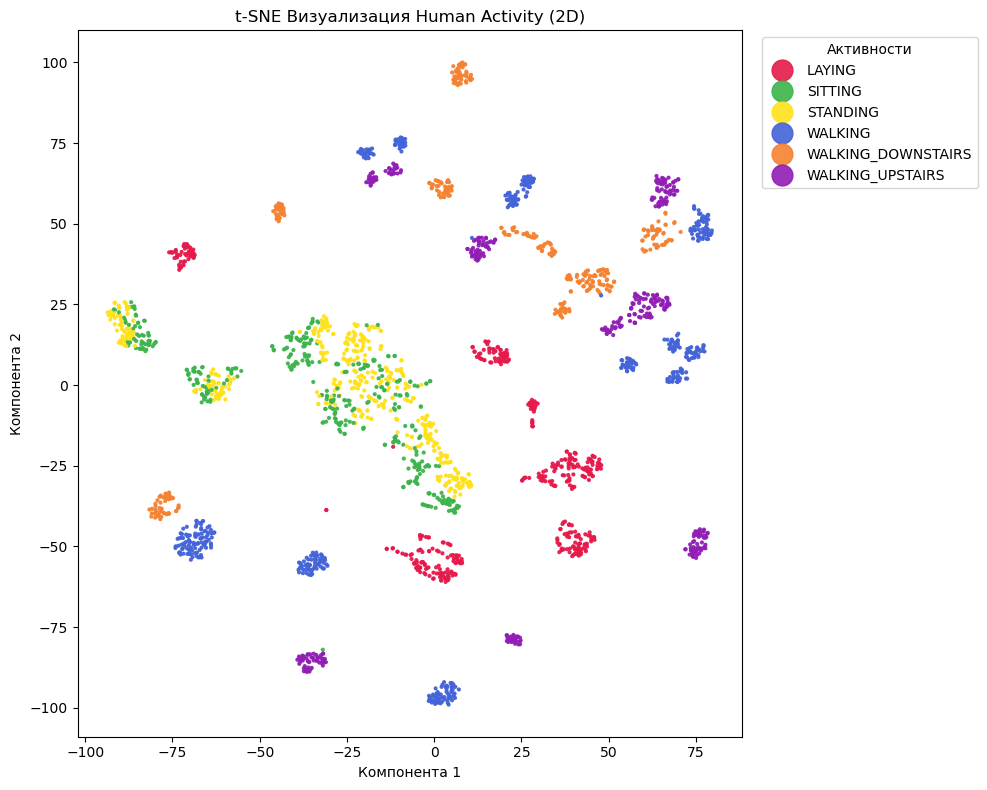

In [6]:
class_names = sorted(list(np.unique(activities)))
num_classes = len(class_names)

mapping = {name: idx for idx, name in enumerate(class_names)}
numeric_labels = np.array([mapping[act] for act in activities])

plt.figure(figsize=(10, 8))

high_contrast_colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', 
    '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe'
]
custom_cmap = ListedColormap(high_contrast_colors[:num_classes])

scatter = plt.scatter(Y[:, 0], Y[:, 1], s=4, c=numeric_labels, cmap=custom_cmap, alpha=0.9)

handles, _ = scatter.legend_elements(num=num_classes)

plt.legend(
    handles=handles,
    labels=class_names,             
    title="Активности", 
    loc="upper left", 
    bbox_to_anchor=(1.02, 1),
    markerscale=2.5
)

plt.title("t-SNE Визуализация Human Activity (2D)")
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.tight_layout()
plt.show()

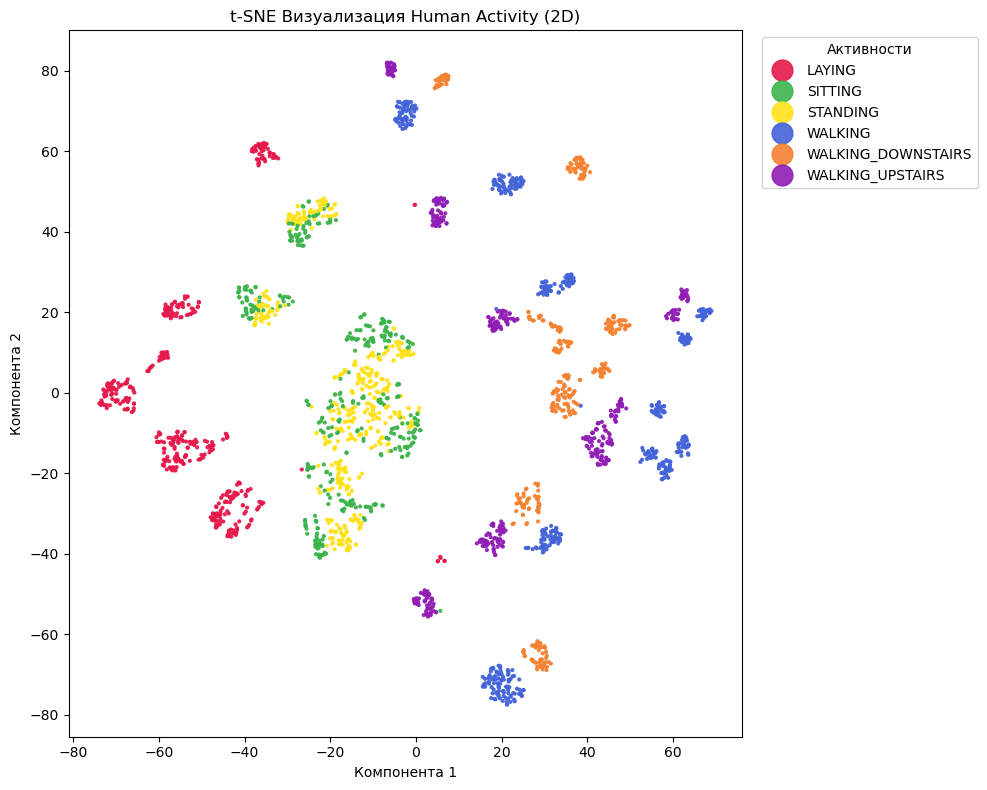

In [34]:
class_names = sorted(list(np.unique(activities)))
num_classes = len(class_names)

mapping = {name: idx for idx, name in enumerate(class_names)}
numeric_labels = np.array([mapping[act] for act in activities])

plt.figure(figsize=(10, 8))

high_contrast_colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', 
    '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe'
]
custom_cmap = ListedColormap(high_contrast_colors[:num_classes])

scatter = plt.scatter(Y_sklearn[:, 0], Y_sklearn[:, 1], s=4, c=numeric_labels, cmap=custom_cmap, alpha=0.9)

handles, _ = scatter.legend_elements(num=num_classes)

plt.legend(
    handles=handles,
    labels=class_names,             
    title="Активности", 
    loc="upper left", 
    bbox_to_anchor=(1.02, 1),
    markerscale=2.5
)

plt.title("t-SNE Визуализация Human Activity (2D)")
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.tight_layout()
plt.show()

В обеих реализациях получилось плюс минус одинаковые результаты:

1) Действия хождение, хождение вверх, хождение вниз разбиты по маленьким кластерам и располагаются рядом друг с другом очень маленькими кластерами
2) Обе модели плохо разделяют действия сидения и стояния, перемешивая их в одни большие кластеры, которые располагаются между лежанием и хождением
3) Хорошо распознавается лежание, хотя в первой моделе оно располагается где-то между сидением и стоянием, когда вторая модель выносит её наружу

Вообще говоря справляется отлично и видно, что действия кластеризованы хорошо